
 Logistic Regression
Accuracy: 0.8097826086956522
Precision: 0.8627450980392157
Recall: 0.8073394495412844
F1 Score: 0.8341232227488151

 SVM
Accuracy: 0.8586956521739131
Precision: 0.9029126213592233
Recall: 0.8532110091743119
F1 Score: 0.8773584905660378

 Decision Tree
Accuracy: 0.75
Precision: 0.8247422680412371
Recall: 0.7339449541284404
F1 Score: 0.7766990291262136

 Random Forest
Accuracy: 0.8369565217391305
Precision: 0.8910891089108911
Recall: 0.8256880733944955
F1 Score: 0.8571428571428571

Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.809783   0.862745  0.807339  0.834123
1                  SVM  0.858696   0.902913  0.853211  0.877358
2        Decision Tree  0.750000   0.824742  0.733945  0.776699
3        Random Forest  0.836957   0.891089  0.825688  0.857143


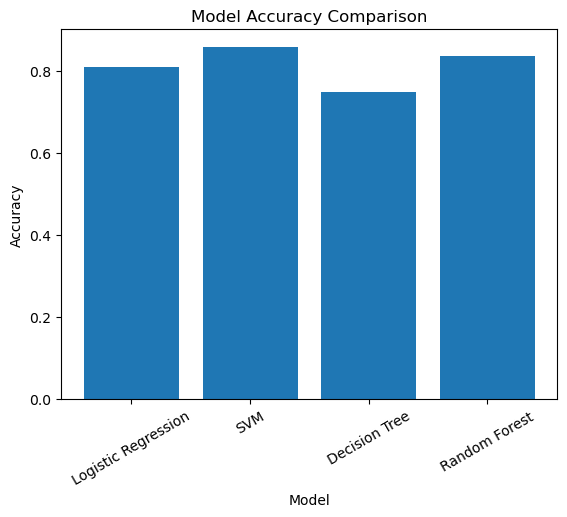

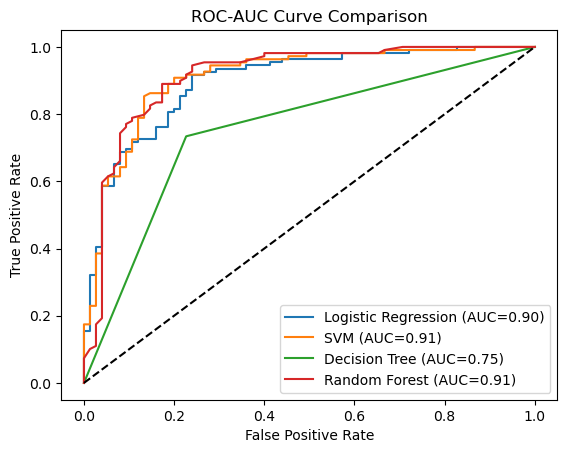

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Load dataset
df = pd.read_csv("heart_disease_uci.csv")

# -----------------------------
# Data Preprocessing
# -----------------------------

# Convert target to binary
df['target'] = (df['num'] > 0).astype(int)

# Drop unnecessary columns
df = df.drop(['id','dataset','num'], axis=1)

# Convert categorical columns into numeric
df = pd.get_dummies(df, drop_first=True)

# Handle missing values
df = df.fillna(df.mean())


# -----------------------------
# Split features and target
# -----------------------------

X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -----------------------------
# Models
# -----------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []


# -----------------------------
# Train and Evaluate
# -----------------------------

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

    print("\n", name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)


# -----------------------------
# Comparison Table
# -----------------------------

results_df = pd.DataFrame(results, columns=[
    "Model","Accuracy","Precision","Recall","F1 Score"
])

print("\nModel Comparison")
print(results_df)


# -----------------------------
# Accuracy Comparison Bar Chart
# -----------------------------

plt.figure()

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)

plt.show()

# -----------------------------
# ROC-AUC Curve
# -----------------------------

plt.figure()

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")


plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")

plt.legend()
plt.show()